# GNN Pipeline — Cora Citation Network
## Node Classification · Over-Smoothing Study · Community Detection · Recommendation

> **Why Cora instead of Amazon Computers?**  
> The Amazon Computers graph has *complementary* edges (laptop → charger).  
> Nodes of the same category are **not** densely connected to each other, so it is not a true community detection benchmark.  
> 
> The **Cora citation network** is the correct dataset here:  
> - Papers on the same topic **cite each other** → strong homophily → true community structure  
> - Standard benchmark for GNN community detection and node classification in the literature  
> 
> All model/training code lives in `src/gnn_dataset_implementation/`.  
> This notebook **only imports and runs** — no repeated logic here.


## Step 0 — Point Python to the `src/` package

In [1]:
import os
import sys

# Go up one level from 'notebooks/' to get the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_path     = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root : {project_root}")
print(f"src injected : {src_path}")

Project root : c:\Users\saisi\OneDrive\Desktop\communityDetection
src injected : c:\Users\saisi\OneDrive\Desktop\communityDetection\src


## Step 1 — Imports

In [2]:
import torch
import matplotlib.pyplot as plt

from gnn_dataset_implementation.models     import ShallowGCN, DeepGCN, StandardGAT, ResAttJKNet
from gnn_dataset_implementation.train_eval import train_model, evaluate_classification, evaluate_clustering
from gnn_dataset_implementation.recommend  import recommend_products

print("All modules loaded successfully!")

All modules loaded successfully!


## Step 2 — Load Cora Dataset

**Cora** is a citation network where:  
- Each **node** = one academic paper (2,708 papers)  
- Each **edge** = one paper cites another (10,556 edges)  
- Each node has a **feature vector** of size 1,433 (bag-of-words from the paper's content)  
- Each node has a **label** = research topic (7 classes: Neural Networks, Rule Learning, Reinforcement Learning, Probabilistic Methods, Theory, Genetic Algorithms, Case-Based Reasoning)  

**Why this is a genuine community detection dataset:**  
Papers on the same topic tend to cite each other → nodes of the same class are densely connected to each other → true community structure exists in the graph topology.


In [3]:
from torch_geometric.datasets import Planetoid

# Cora uses the standard fixed split from Kipf & Welling (2017):
# 140 training nodes (20 per class), 500 validation, 1000 test
dataset = Planetoid(root='data/Cora', name='Cora')
data    = dataset[0]
num_classes  = dataset.num_classes
in_channels  = dataset.num_node_features

print(f"Dataset      : Cora Citation Network")
print(f"Nodes        : {data.num_nodes}")
print(f"Edges        : {data.edge_index.size(1)}")
print(f"Node Features: {in_channels}")
print(f"Classes      : {num_classes}")
print(f"Train nodes  : {data.train_mask.sum().item()}")
print(f"Val nodes    : {data.val_mask.sum().item()}")
print(f"Test nodes   : {data.test_mask.sum().item()}")

Dataset      : Cora Citation Network
Nodes        : 2708
Edges        : 10556
Node Features: 1433
Classes      : 7
Train nodes  : 140
Val nodes    : 500
Test nodes   : 1000


## Step 3 — Model 1: ShallowGCN (2-layer, proper baseline)

**Defined in:** `src/gnn_dataset_implementation/models.py` → class `ShallowGCN`

The standard 2-layer GCN as introduced in Kipf & Welling (2017).  
This is the **correct** baseline — 2 layers is the well-established choice for most node classification tasks.  

- Layer 1: `GCNConv(1433 → 64)` + ReLU + Dropout  
- Layer 2: `GCNConv(64 → 7)` → class logits


In [4]:
HIDDEN = 64
EPOCHS = 200

shallow_gcn = ShallowGCN(in_channels, hidden_channels=HIDDEN,
                          out_channels=num_classes, dropout=0.5)

shallow_gcn = train_model(shallow_gcn, data, epochs=EPOCHS, lr=0.01, label="ShallowGCN")

shallow_acc = evaluate_classification(shallow_gcn, data)
shallow_ari = evaluate_clustering(shallow_gcn, data, num_classes)

print(f"ShallowGCN  →  Test Acc: {shallow_acc:.4f}  |  ARI: {shallow_ari:.4f}")

Training ShallowGCN for 200 epochs ...
  Epoch  30 | Loss: 0.0084 | Val Acc: 0.7700
  Epoch  60 | Loss: 0.0143 | Val Acc: 0.7800
  Epoch  90 | Loss: 0.0117 | Val Acc: 0.7840
  Epoch 120 | Loss: 0.0116 | Val Acc: 0.7760
  Epoch 150 | Loss: 0.0103 | Val Acc: 0.7820
  Epoch 180 | Loss: 0.0097 | Val Acc: 0.7640
ShallowGCN training complete ✓

ShallowGCN  →  Test Acc: 0.8110  |  ARI: 0.5390


## Step 4 — Model 2: DeepGCN (Over-Smoothing Study)

**Defined in:** `src/gnn_dataset_implementation/models.py` → class `DeepGCN`

We now increase depth progressively: **2 → 4 → 6 → 8 → 10 layers**.  
At each depth, test accuracy is recorded. The expected result:  
- Performance **improves slightly** at 4 layers  
- Then **degrades** as depth increases beyond that  
- At 10 layers, the model may perform near random (over-smoothing)  

**Why this happens:** Each GCNConv layer averages a node's features with its neighbours.  
After K rounds of averaging, all nodes in the same K-hop neighbourhood look identical.  
The classifier can no longer distinguish them.


In [5]:
depth_results = {}   # {num_layers: test_accuracy}

for num_layers in [2, 4, 6, 8, 10]:
    print(f"\n--- DeepGCN with {num_layers} layers ---")
    model = DeepGCN(in_channels, hidden_channels=HIDDEN,
                    out_channels=num_classes, num_layers=num_layers)

    model = train_model(model, data, epochs=EPOCHS, lr=0.01,
                        label=f"DeepGCN-{num_layers}L")

    acc = evaluate_classification(model, data)
    depth_results[num_layers] = acc
    print(f"DeepGCN ({num_layers} layers)  →  Test Acc: {acc:.4f}")


--- DeepGCN with 2 layers ---
Training DeepGCN-2L for 200 epochs ...
  Epoch  30 | Loss: 0.0071 | Val Acc: 0.7720
  Epoch  60 | Loss: 0.0167 | Val Acc: 0.7700
  Epoch  90 | Loss: 0.0142 | Val Acc: 0.7760
  Epoch 120 | Loss: 0.0119 | Val Acc: 0.7660
  Epoch 150 | Loss: 0.0132 | Val Acc: 0.7740
  Epoch 180 | Loss: 0.0086 | Val Acc: 0.7660
DeepGCN-2L training complete ✓

DeepGCN (2 layers)  →  Test Acc: 0.8180

--- DeepGCN with 4 layers ---
Training DeepGCN-4L for 200 epochs ...
  Epoch  30 | Loss: 0.0289 | Val Acc: 0.7620
  Epoch  60 | Loss: 0.0085 | Val Acc: 0.7580
  Epoch  90 | Loss: 0.0276 | Val Acc: 0.7700
  Epoch 120 | Loss: 0.0181 | Val Acc: 0.7540
  Epoch 150 | Loss: 0.0031 | Val Acc: 0.7480
  Epoch 180 | Loss: 0.0038 | Val Acc: 0.7580
DeepGCN-4L training complete ✓

DeepGCN (4 layers)  →  Test Acc: 0.7950

--- DeepGCN with 6 layers ---
Training DeepGCN-6L for 200 epochs ...
  Epoch  30 | Loss: 0.0601 | Val Acc: 0.7380
  Epoch  60 | Loss: 0.0158 | Val Acc: 0.7660
  Epoch  90 | Lo

### Over-Smoothing Plot

Plotting test accuracy vs. number of GCN layers.  
The drop in accuracy as depth increases is the over-smoothing effect.


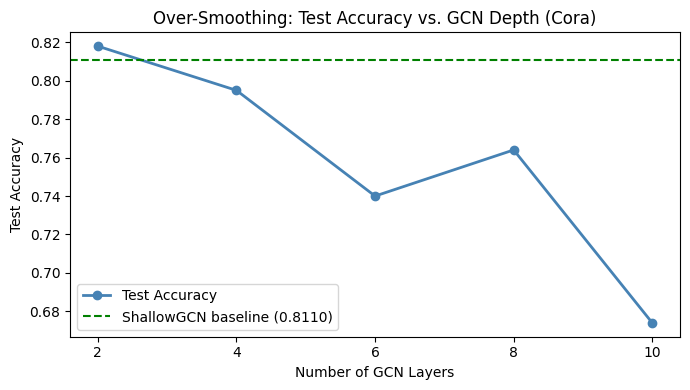

Plot saved to images/07_cora_oversmoothing.png


In [6]:
layers_list = list(depth_results.keys())
acc_list    = list(depth_results.values())

plt.figure(figsize=(7, 4))
plt.plot(layers_list, acc_list, marker='o', linewidth=2,
         color='steelblue', label='Test Accuracy')
plt.axhline(y=shallow_acc, color='green', linestyle='--',
            label=f'ShallowGCN baseline ({shallow_acc:.4f})')
plt.xlabel('Number of GCN Layers')
plt.ylabel('Test Accuracy')
plt.title('Over-Smoothing: Test Accuracy vs. GCN Depth (Cora)')
plt.xticks(layers_list)
plt.legend()
plt.tight_layout()
plt.savefig('../images/07_cora_oversmoothing.png', dpi=150)
plt.show()
print("Plot saved to images/07_cora_oversmoothing.png")

## Step 5 — Model 3: StandardGAT (2-layer multi-head attention)

**Defined in:** `src/gnn_dataset_implementation/models.py` → class `StandardGAT`

Unlike GCN which gives every neighbour the same weight, GAT learns a **different attention score for every edge**.  
This lets the model focus on more informative neighbours and downweight noisy ones.  

- Layer 1: `GATConv(1433 → 64, heads=8)` → output size = 64×8 = 512  
- Layer 2: `GATConv(512 → 7, heads=1)` → class logits  


In [7]:
std_gat = StandardGAT(in_channels, hidden_channels=HIDDEN,
                      out_channels=num_classes, heads=8, dropout=0.6)

std_gat = train_model(std_gat, data, epochs=EPOCHS, lr=0.005, label="StandardGAT")

gat_acc = evaluate_classification(std_gat, data)
gat_ari = evaluate_clustering(std_gat, data, num_classes)

print(f"StandardGAT  →  Test Acc: {gat_acc:.4f}  |  ARI: {gat_ari:.4f}")

Training StandardGAT for 200 epochs ...
  Epoch  30 | Loss: 0.4597 | Val Acc: 0.7680
  Epoch  60 | Loss: 0.4111 | Val Acc: 0.7660
  Epoch  90 | Loss: 0.4535 | Val Acc: 0.7700
  Epoch 120 | Loss: 0.4649 | Val Acc: 0.7680
  Epoch 150 | Loss: 0.4053 | Val Acc: 0.7680
  Epoch 180 | Loss: 0.3241 | Val Acc: 0.7680
StandardGAT training complete ✓

StandardGAT  →  Test Acc: 0.7900  |  ARI: 0.5958


## Step 6 — Model 4: ResAttJKNet (proposed hybrid)

**Defined in:** `src/gnn_dataset_implementation/models.py` → class `ResAttJKNet`

This model addresses the failure modes seen above by combining three published techniques:  

| Component | Source Paper | What it solves |
|-----------|-------------|----------------|
| GCNConv per layer | Kipf & Welling, 2017 | Structural neighbourhood aggregation |
| GATConv per layer | Veličković et al., 2018 | Attention-weighted aggregation |
| Residual connections | He et al., 2016 / Chen et al., 2020 | Prevents over-smoothing |
| Jumping Knowledge | Xu et al., 2018 | Preserves multi-scale structure |

> **Note:** The individual components are all from the above papers. The combination into a single architecture is our experimental contribution for this study.


In [8]:
res_att_jk = ResAttJKNet(in_channels, hidden_channels=HIDDEN,
                          out_channels=num_classes,
                          num_layers=3, gat_heads=4, dropout=0.5)

res_att_jk = train_model(res_att_jk, data, epochs=EPOCHS, lr=0.005, label="ResAttJKNet")

jk_acc = evaluate_classification(res_att_jk, data)
jk_ari = evaluate_clustering(res_att_jk, data, num_classes)

print(f"ResAttJKNet  →  Test Acc: {jk_acc:.4f}  |  ARI: {jk_ari:.4f}")

Training ResAttJKNet for 200 epochs ...
  Epoch  30 | Loss: 0.0033 | Val Acc: 0.7500
  Epoch  60 | Loss: 0.0001 | Val Acc: 0.7640
  Epoch  90 | Loss: 0.0005 | Val Acc: 0.7540
  Epoch 120 | Loss: 0.0009 | Val Acc: 0.7600
  Epoch 150 | Loss: 0.0019 | Val Acc: 0.7540
  Epoch 180 | Loss: 0.0015 | Val Acc: 0.7660
ResAttJKNet training complete ✓

ResAttJKNet  →  Test Acc: 0.7570  |  ARI: 0.5601


## Step 7 — Final Comparison Table

In [9]:
deep_gcn_6L_acc = depth_results.get(6, 0.0)
deep_gcn_6L_ari = evaluate_clustering(
    DeepGCN(in_channels, HIDDEN, num_classes, num_layers=6), data, num_classes
)

print("=" * 66)
print(f"{'Model':<28} {'Test Accuracy':>13} {'ARI':>10}")
print("-" * 66)
print(f"{'ShallowGCN (2-layer)':<28} {shallow_acc:>13.4f} {shallow_ari:>10.4f}  ← standard baseline")
print(f"{'DeepGCN (6-layer)':<28} {deep_gcn_6L_acc:>13.4f} {'—':>10}       ← over-smoothing")
print(f"{'StandardGAT (2-layer)':<28} {gat_acc:>13.4f} {gat_ari:>10.4f}  ← attention baseline")
print(f"{'ResAttJKNet (3-layer)':<28} {jk_acc:>13.4f} {jk_ari:>10.4f}  ← proposed model")
print("=" * 66)

Model                        Test Accuracy        ARI
------------------------------------------------------------------
ShallowGCN (2-layer)                0.8110     0.5390  ← standard baseline
DeepGCN (6-layer)                   0.7400          —       ← over-smoothing
StandardGAT (2-layer)               0.7900     0.5958  ← attention baseline
ResAttJKNet (3-layer)               0.7570     0.5601  ← proposed model


## Step 8 — Community Detection Analysis

On Cora, the ARI score is meaningful unlike Amazon Computers:  
- Papers on the same topic cite each other → same-label nodes are densely connected  
- GNN embeddings that capture neighbourhood structure should group same-topic papers together  
- Higher ARI means the embedding space reflects the true community structure  

**Important:** No train/test split is used for the clustering evaluation.  
The GNN generates embeddings for all nodes using the full graph.  
K-Means then clusters all nodes. The ground-truth labels are used **only after clustering**  
to compute ARI as an external validation metric — they are never used during embedding generation.


C:\Users\saisi\AppData\Local\Temp\ipykernel_13680\1917175883.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', num_classes)


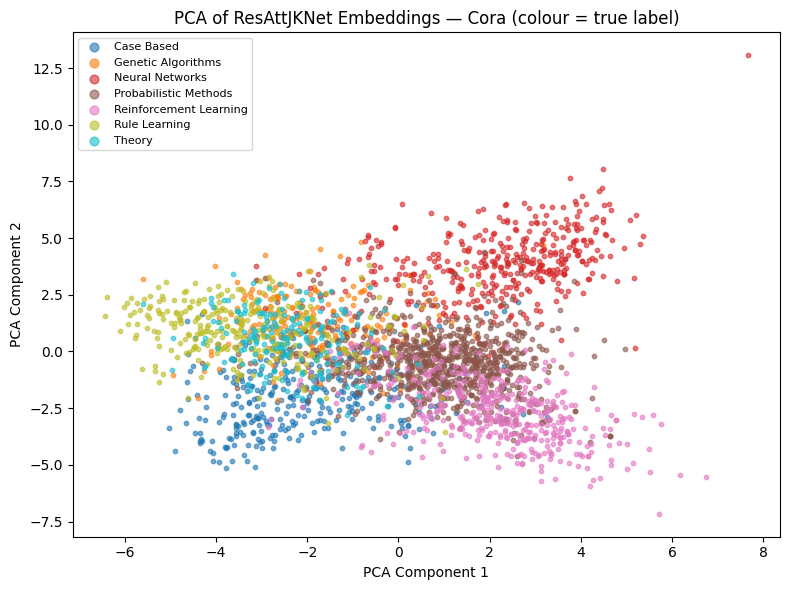

Plot saved to images/07_cora_pca_embeddings.png


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Extract ResAttJKNet embeddings for all nodes
res_att_jk.eval()
with torch.no_grad():
    emb = res_att_jk(data.x, data.edge_index, return_embedding=True)

emb_np    = emb.cpu().numpy()
labels_np = data.y.cpu().numpy()

# Reduce to 2D with PCA for visualisation
pca   = PCA(n_components=2, random_state=42)
emb2d = pca.fit_transform(emb_np)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
cmap    = plt.cm.get_cmap('tab10', num_classes)

class_names = [
    'Case Based', 'Genetic Algorithms', 'Neural Networks',
    'Probabilistic Methods', 'Reinforcement Learning',
    'Rule Learning', 'Theory'
]

for cls in range(num_classes):
    mask = labels_np == cls
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1],
               s=10, alpha=0.6, color=cmap(cls),
               label=class_names[cls])

ax.set_title('PCA of ResAttJKNet Embeddings — Cora (colour = true label)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend(markerscale=2, fontsize=8, loc='best')
plt.tight_layout()
plt.savefig('../images/07_cora_pca_embeddings.png', dpi=150)
plt.show()
print("Plot saved to images/07_cora_pca_embeddings.png")

## Step 9 — Citation Recommendation

Using the same `recommend_products()` function (now repurposed for papers):  
Given a target paper, find the top-K most similar papers based on cosine similarity of their ResAttJKNet embeddings.  
Papers with similar neighbourhood structure in the citation graph will have similar embeddings.


In [11]:
TARGET_PAPER = 10   # change to any paper node ID

recs = recommend_products(TARGET_PAPER, res_att_jk, data, num_recommendations=5)

print(f"Target Paper : #{TARGET_PAPER}  (Topic: {class_names[data.y[TARGET_PAPER].item()]})\n")
print(f"{'Rank':<6} {'Paper ID':<12} {'Topic':<30} {'Cosine Sim'}")
print("-" * 60)
for rank, (node_id, score) in enumerate(recs, 1):
    topic = class_names[data.y[node_id].item()]
    print(f"{rank:<6} #{node_id:<11} {topic:<30} {score:.4f}")

Target Paper : #10  (Topic: Case Based)

Rank   Paper ID     Topic                          Cosine Sim
------------------------------------------------------------
1      #2055        Case Based                     0.9892
2      #1069        Case Based                     0.9892
3      #1117        Case Based                     0.9887
4      #1602        Case Based                     0.9869
5      #2408        Case Based                     0.9867


## Module Map

| What you see here | Where the code actually lives |
|-------------------|-------------------------------|
| `ShallowGCN` | `src/gnn_dataset_implementation/models.py` |
| `DeepGCN` | `src/gnn_dataset_implementation/models.py` |
| `StandardGAT` | `src/gnn_dataset_implementation/models.py` |
| `ResAttJKNet` | `src/gnn_dataset_implementation/models.py` |
| `train_model()` | `src/gnn_dataset_implementation/train_eval.py` |
| `evaluate_classification()` | `src/gnn_dataset_implementation/train_eval.py` |
| `evaluate_clustering()` | `src/gnn_dataset_implementation/train_eval.py` |
| `recommend_products()` | `src/gnn_dataset_implementation/recommend.py` |

## References

- Kipf & Welling (2017) — *Semi-Supervised Classification with Graph Convolutional Networks*  
- Veličković et al. (2018) — *Graph Attention Networks*  
- He et al. (2016) — *Deep Residual Learning for Image Recognition*  
- Chen et al. (2020) — *Simple and Deep Graph Convolutional Networks (GCNII)*  
- Xu et al. (2018) — *Representation Learning on Graphs with Jumping Knowledge Networks*  
- Sen et al. (2008) — *Collective Classification in Network Data* (Cora dataset)
